## Data Preparation

In this notebook we fetch and prepare the historical log return data required to estimate and forecast volatility.

Imports

In [4]:
from ib_insync import *
import random
import asyncio
import pandas as pd
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 10)
import numpy as np
import matplotlib.pyplot as plt

## Data Retrieval
We request historical price data for 2800.HK (a Hong Kong index ETF representing the Hang Seng Index) using Interactive Brokers Trader Workstation (TWS).<br>
The data is then prepared by converting close prices into log returns.

In [27]:
util.startLoop()

# Contract definitions
contracts = {
    '2800.HK': Stock('2800', 'SEHK', 'HKD'),
}

ret_df = pd.DataFrame()
ib = IB()

async def fetch_ret(contracts: dict = contracts) -> pd.DataFrame:
    """Fetch historical daily midpoint prices and compute log returns."""
    global ret_df
    await ib.connectAsync('127.0.0.1', 7497, clientId=random.randint(1, 99999))

    for symbol, contract in contracts.items():
        print("\n=======================================")
        print(f"Fetching: {symbol}")

        all_bars = []
        seen_dates = set()
        dt = ''

        while True:
            bars = await ib.reqHistoricalDataAsync(
                contract,
                endDateTime=dt,
                durationStr='10 Y',
                barSizeSetting='1 day',
                whatToShow='Trades',
                useRTH=False,
                formatDate=1
            )

            if not bars:
                print(f"{symbol}: No more bars")
                break

            added = 0
            for bar in bars:
                if bar.date not in seen_dates:
                    seen_dates.add(bar.date)
                    all_bars.append(bar)
                    added += 1

            print(f"{symbol}: Retrieved until {bars[0].date}, Added {added}")

            if added == 0:
                print(f"{symbol}: Reached oldest")
                break

            dt = bars[0].date
            await asyncio.sleep(0.4)

        if len(all_bars) == 0:
            print(f"⚠ No data for {symbol}")
            continue

        df = util.df(all_bars)
        df['date'] = pd.to_datetime(df['date'])
        df = df.sort_values('date').drop_duplicates(subset='date')
        df.set_index('date', inplace=True)

        # Log returns
        log_ret = np.log(df['close'] / df['close'].shift(1)).rename(symbol)

        # Merge into master df if more contracts are passed
        ret_df = ret_df.join(log_ret, how='outer')

    ib.disconnect()
    print("Fetch done.")
    return ret_df


# Run
ret_data = asyncio.run(fetch_ret(contracts))
ret_data = ret_data.sort_index().dropna(how='all')
print("Shape:", ret_data.shape)



Fetching: 2800.HK
2800.HK: Retrieved until 2015-12-14, Added 2462
2800.HK: Retrieved until 2005-12-19, Added 2461
2800.HK: Retrieved until 2002-05-13, Added 896
2800.HK: Retrieved until 2002-05-13, Added 0
2800.HK: Reached oldest
Fetch done.
Shape: (5818, 1)


### Volatility Proxy Construction
To model future volatility, we transform the daily log returns into realized volatility.<br> 
We square returns to approximate variance, then compute a 21-day rolling sum (about one trading month). <br>
Finally, we apply a logarithmic transformation to improve normality and reduce the influence of extreme values.

In [20]:
df = ret_data.copy() #copy to preserve the original returns

df = df**2 # Square returns → daily variance

# Monthly realized variance: sum of squared returns over a 21-day window
# Forward-looking shift (-21): aligns each target with the prior day's features
df = df.rolling(21).sum().shift(-21) 

# Log-transform stabilizes variance and mitigates extreme outliers
# Add epsilon (1e-12) to avoid log(0)
df = 0.5 * np.log(df + 1e-12)

### Extract Target Series
We isolate the realized volatility target for the 2800.HK ETF and drop any remaining NaN values caused by rolling-window operations.

In [21]:
hsi = df['2800.HK'].dropna() # remove NaNs introduced by shifting and rolling
hsi # Quick display for sanity check

date
2002-05-14   -3.178702
2002-05-15   -3.173177
2002-05-16   -3.122987
2002-05-17   -3.165196
2002-05-21   -3.309047
                ...   
2025-11-04   -2.941056
2025-11-05   -2.930590
2025-11-06   -3.011233
2025-11-07   -3.003996
2025-11-10   -3.021088
Name: 2800.HK, Length: 5797, dtype: float64

### Train / Out-of-Sample Split

To properly evaluate model performance, we divide the realized volatility series into:
- **Training set**: data before 2022-01-01  
- **Out-of-sample set**: data from 2022-01-01 onward 

In [28]:
# Define the cutoff date for training vs. out-of-sample evaluation
split_date = '2022-01-01'

# Pre-2022 data used to train the model (completely historical)
train_df = hsi[hsi.index < split_date]

# Holdout period used strictly for forward performance evaluation
oos = hsi[hsi.index >= split_date]

train_df, oos # Quick display for sanity check

(date
 2002-05-14   -3.178702
 2002-05-15   -3.173177
 2002-05-16   -3.122987
 2002-05-17   -3.165196
 2002-05-21   -3.309047
                 ...   
 2021-12-24   -2.850449
 2021-12-28   -2.850886
 2021-12-29   -2.807102
 2021-12-30   -2.794930
 2021-12-31   -2.787847
 Name: 2800.HK, Length: 4847, dtype: float64,
 date
 2022-01-03   -2.686753
 2022-01-04   -2.686997
 2022-01-05   -2.712448
 2022-01-06   -2.677758
 2022-01-07   -2.711836
                 ...   
 2025-11-04   -2.941056
 2025-11-05   -2.930590
 2025-11-06   -3.011233
 2025-11-07   -3.003996
 2025-11-10   -3.021088
 Name: 2800.HK, Length: 950, dtype: float64)

### Export Processed Data

These datasets are saved so that other notebooks in the workflow can load consistent return and volatility inputs without re-running the data retrieval and transformation steps. 

In [23]:
# ret_data.to_excel('../data/hsi_log_ret.xlsx')
# oos.to_excel('../data/hsi_vol_oos.xlsx')
# train_df.to_excel('../data/hsi_vol_train.xlsx')
# hsi.to_excel('../data/hsi_vol.xlsx')

In [3]:
log_ret = pd.read_excel('../data/hsi_log_ret.xlsx')

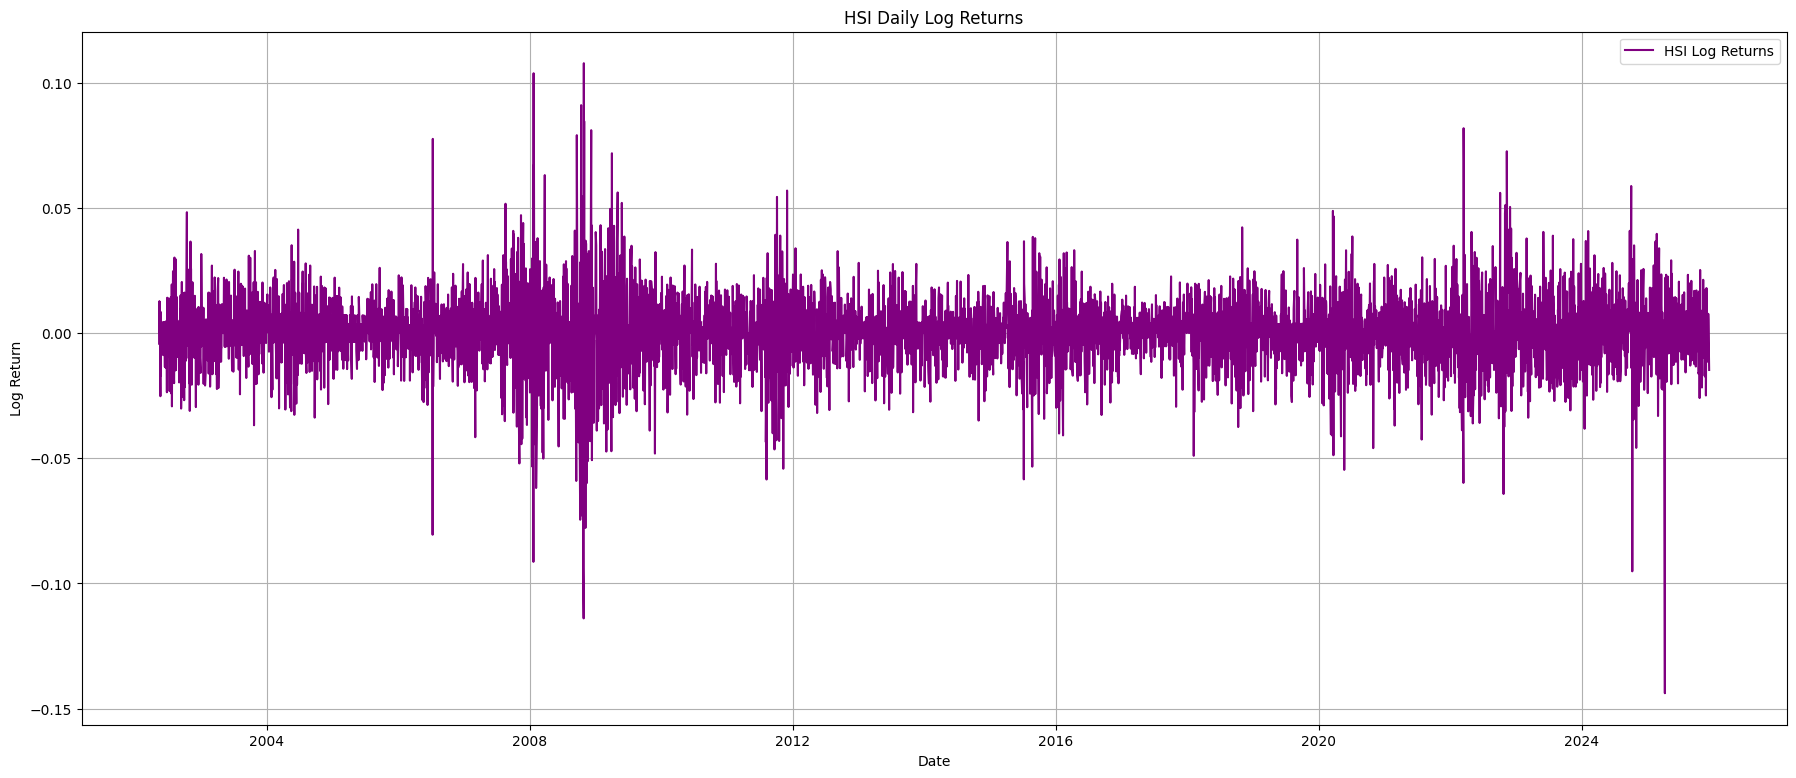

In [7]:
plt.figure(figsize=(22,9))
plt.plot(log_ret['date'], log_ret['2800.HK'], label='HSI Log Returns', color='purple')
plt.title('HSI Daily Log Returns')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.legend()
plt.grid()
